<a href="https://colab.research.google.com/github/pitzsb1/dl-practice/blob/main/02_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6장. 로지스틱 회귀 모델: 참 거짓 판단하기

## 5. 텐서플로에서 실행하는 로지스틱 회귀 모델

### 1.환경 준비

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [18]:
x = np.array([2, 4, 6, 8, 10, 12, 14])
y = np.array([0, 0, 0, 1, 1, 1, 1])

### 3. 모델 실행

In [19]:
model = Sequential()
model.add(Dense(1, input_dim=1, activation='sigmoid'))

# 교차 엔트로피 오차 함수를 이용하기 위하여 'binary_crossentropy'로 설정합니다.
model.compile(optimizer='sgd' ,loss='binary_crossentropy')
model.fit(x, y, epochs=100, verbose=0) #verbose=1 진행 화면 출력, verbose=0 진행 화면 출력 안함.

### 4. 모델 테스트

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


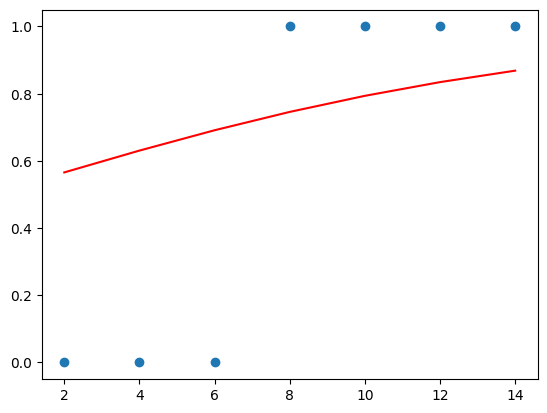

In [20]:
# 그래프로 확인해 봅니다.

plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')
plt.show()

In [21]:
import tensorflow as tf

# 임의의 학습 시간을 집어넣어 합격 예상 확률을 예측해 보겠습니다.

hour = 7
#prediction = model.predict([hour]) #텐서플로 2.9.0 까지만 가능

input_data = tf.constant([[hour]])
prediction = model.predict(input_data)[0][0]


print("%.f시간을 공부할 경우, 합격 예상 확률은 %.01f%%입니다" % (hour, prediction * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
7시간을 공부할 경우, 합격 예상 확률은 71.9%입니다


# 실습 문제

epoch, loss type 등을 바꿔서 실행해보고 결과를 비교 후 이유를 적어보세요

- 파라미터 변경사항 작성
- 결과 비교 작성
- 이유 작성

In [23]:
# epoch = 50, loss type = 평균제곱오차

model.compile(optimizer='sgd' ,loss='mae')
model.fit(x, y, epochs=50, verbose=0)

# 결과 비교

epoch 수를 줄이면 모델이 더 짧게 학습하기 때문에 오차가 늘어난다. 로지스틱 회귀분석에서 loss type을 평균 절대 오차로 바꾸면 모델이 이상치에 덜 민감해지기 때문에 명확한 결과 도출에는 어려움을 보인다.